<a href="https://colab.research.google.com/github/panzehui0206/AI4S-365days/blob/main/%E7%AC%AC%E4%BA%8C%E7%AB%A0%20%E7%94%9F%E5%91%BD%E7%A7%91%E5%AD%A6%E7%9A%84%E2%80%9C%E8%87%AA%E7%84%B6%E8%AF%AD%E8%A8%80%E2%80%9D%E2%80%94%E2%80%94%E5%BA%8F%E5%88%97%E5%A4%84%E7%90%86/Note3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**2026.4.16**

开始学习吧！

In [1]:
# =============================================
# Cell 1：导入库 + 定义打分规则
# =============================================
import numpy as np
import matplotlib.pyplot as plt

# DNA 简单打分规则
MATCH = 2
MISMATCH = -1
GAP = -1

def score(a, b):
    """返回两个碱基的比对得分"""
    return MATCH if a == b else MISMATCH

print("✅ 打分规则：匹配={}，错配={}，空位={}".format(MATCH, MISMATCH, GAP))

✅ 打分规则：匹配=2，错配=-1，空位=-1


设置打分规则是为了量化“两条序列有多像”。

两条 DNA 序列的相似程度往往暗示了它们是否**同源**或具有**相似功能**。

生物学上一般根据不同场景选择不同的**替换矩阵**，它们是基于大量真实生物学数据统计出来的。

DNA 比对通常考虑**碱基替换模型**（如 Jukes-Cantor、Kimura-80），它们根据进化距离计算不同碱基间相互转换的概率。

最常用的**蛋白质替换矩阵**是 BLOSUM62 和 PAM。

In [2]:
# =============================================
# Cell 2：NW 算法核心 —— 填表与回溯
# =============================================
def needleman_wunsch(seqA, seqB):
    rows = len(seqA) + 1
    cols = len(seqB) + 1

    # 初始化矩阵，第一行/第一列累加空位罚分
    mat = np.zeros((rows, cols), dtype=int)
    for i in range(1, rows):
        mat[i, 0] = mat[i-1, 0] + GAP
    for j in range(1, cols):
        mat[0, j] = mat[0, j-1] + GAP

    # 动态规划填表
    for i in range(1, rows):
        for j in range(1, cols):
            diag = mat[i-1, j-1] + score(seqA[i-1], seqB[j-1])  # 对角线
            up   = mat[i-1, j] + GAP                              # 上方插入空位
            left = mat[i, j-1] + GAP                              # 左方插入空位
            mat[i, j] = max(diag, up, left)

    # 回溯，从右下角开始
    alignA = []
    alignB = []
    i, j = rows - 1, cols - 1
    while i > 0 or j > 0:
        current = mat[i, j]
        if i > 0 and j > 0 and current == mat[i-1, j-1] + score(seqA[i-1], seqB[j-1]):
            alignA.append(seqA[i-1])
            alignB.append(seqB[j-1])
            i -= 1
            j -= 1
        elif i > 0 and current == mat[i-1, j] + GAP:
            alignA.append(seqA[i-1])
            alignB.append('-')
            i -= 1
        else:
            alignA.append('-')
            alignB.append(seqB[j-1])
            j -= 1

    # 反转得到正确顺序
    alignA = ''.join(reversed(alignA))
    alignB = ''.join(reversed(alignB))
    score_val = mat[-1, -1]

    return alignA, alignB, score_val, mat

# 测试两条短 DNA 序列
seqA = "ATGC"
seqB = "ATCG"
alignA, alignB, score_val, mat = needleman_wunsch(seqA, seqB)

print(f"序列 A: {seqA}")
print(f"序列 B: {seqB}")
print(f"最优比对得分: {score_val}")
print("比对结果:")
print(alignA)
print(alignB)

序列 A: ATGC
序列 B: ATCG
最优比对得分: 4
比对结果:
AT-GC
ATCG-


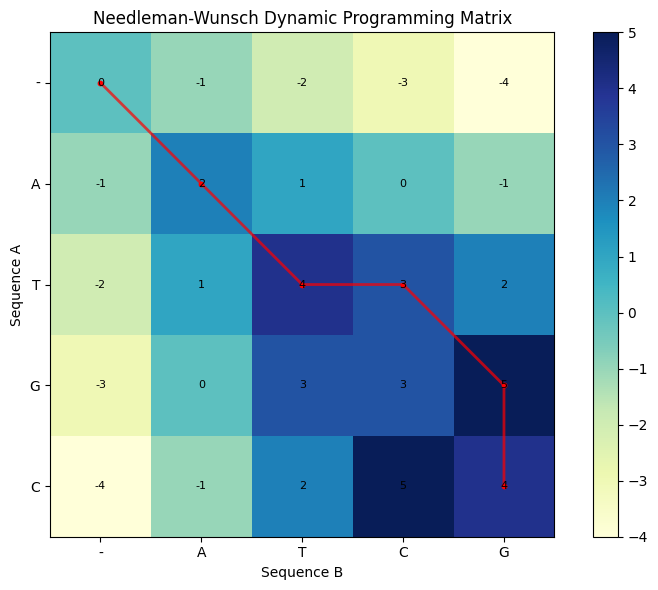

In [3]:
# =============================================
# Cell 3：矩阵可视化 + 回溯路径绘制
# =============================================
def traceback_path(mat, seqA, seqB):
    """返回回溯路径上的坐标列表"""
    path = []
    i, j = len(seqA), len(seqB)
    path.append((i, j))
    while i > 0 or j > 0:
        current = mat[i, j]
        if i > 0 and j > 0 and current == mat[i-1, j-1] + score(seqA[i-1], seqB[j-1]):
            i -= 1; j -= 1
        elif i > 0 and current == mat[i-1, j] + GAP:
            i -= 1
        else:
            j -= 1
        path.append((i, j))
    return path

def plot_matrix(mat, seqA, seqB, path=None):
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(mat, cmap='YlGnBu')

    # 标注数值
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, str(mat[i, j]), ha='center', va='center', fontsize=8)

    # 设置坐标轴
    ax.set_xticks(range(len(seqB) + 1))
    ax.set_yticks(range(len(seqA) + 1))
    ax.set_xticklabels(['-'] + list(seqB))
    ax.set_yticklabels(['-'] + list(seqA))
    ax.set_xlabel('Sequence B')
    ax.set_ylabel('Sequence A')

    # 画回溯路径
    if path:
        path_y, path_x = zip(*path)
        ax.plot(path_x, path_y, 'r-', linewidth=2, alpha=0.7)
        ax.scatter(path_x, path_y, color='red', s=10)

    plt.colorbar(im, ax=ax)
    plt.title('Needleman-Wunsch Dynamic Programming Matrix')
    plt.tight_layout()
    plt.show()

path = traceback_path(mat, seqA, seqB)
plot_matrix(mat, seqA, seqB, path)

纵轴：序列 A，最上方多一行 - 代表空前缀。

横轴：序列 B，最左侧多一列 - 代表空前缀。

每个格子：**mat[i][j]**，表示序列 A 的前 i 个字符与序列 B 的前 j 个字符进行最优全局比对能达到的最高分数。

深色（蓝绿）：分数较高的格子，代表该局部比对组合得分高。

浅色（黄白）：分数较低的格子，代表该局部比对组合得分低。

In [5]:
# =============================================
# Cell 4：蛋白质比对（BLOSUM62 替换矩阵）
# =============================================
import sys
if 'google.colab' in sys.modules:
    !pip install biopython -q

from Bio.Align import substitution_matrices
import numpy as np

# 加载 BLOSUM62 矩阵
blosum62 = substitution_matrices.load("BLOSUM62")

def protein_score(a, b):
    """使用 BLOSUM62 返回氨基酸替换得分"""
    try:
        return blosum62[a, b]
    except KeyError:
        return -4  # 对罕见字符返回惩罚

def needleman_wunsch_protein(seqA, seqB):
    rows = len(seqA) + 1
    cols = len(seqB) + 1
    mat = np.zeros((rows, cols), dtype=int)
    for i in range(1, rows):
        mat[i, 0] = mat[i-1, 0] + GAP
    for j in range(1, cols):
        mat[0, j] = mat[0, j-1] + GAP

    for i in range(1, rows):
        for j in range(1, cols):
            diag = mat[i-1, j-1] + protein_score(seqA[i-1], seqB[j-1])
            up   = mat[i-1, j] + GAP
            left = mat[i, j-1] + GAP
            mat[i, j] = max(diag, up, left)

    # 回溯
    alignA, alignB = [], []
    i, j = rows-1, cols-1
    while i > 0 or j > 0:
        current = mat[i, j]
        if i > 0 and j > 0 and current == mat[i-1, j-1] + protein_score(seqA[i-1], seqB[j-1]):
            alignA.append(seqA[i-1]); alignB.append(seqB[j-1]); i-=1; j-=1
        elif i > 0 and current == mat[i-1, j] + GAP:
            alignA.append(seqA[i-1]); alignB.append('-'); i-=1
        else:
            alignA.append('-'); alignB.append(seqB[j-1]); j-=1

    return ''.join(reversed(alignA)), ''.join(reversed(alignB)), mat[-1, -1], mat

# 测试两条短肽
pepA = "MALWMR"
pepB = "MALWTR"
alignA, alignB, score_val, mat = needleman_wunsch_protein(pepA, pepB)
print(f"肽 A: {pepA}")
print(f"肽 B: {pepB}")
print(f"比对得分: {score_val}")
print(alignA)
print(alignB)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 40.0 MB/s eta 0:00:00
肽 A: MALWMR
肽 B: MALWTR
比对得分: 28
MALWMR
MALWTR


In [6]:
# =============================================
# Cell 5：真实蛋白片段比对
# =============================================
human_tp53_frag = "MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLSPDDIEQWFTEDPGP"
mouse_tp53_frag = "MEEPQSDPSVEPPLSQETFSGLWKLLPPEDILPSPHCMDDLLLPQDVEEFFEGP"

alignA, alignB, score_val, mat = needleman_wunsch_protein(human_tp53_frag, mouse_tp53_frag)
print("人类 TP53 片段:\n", human_tp53_frag)
print("小鼠 TP53 片段:\n", mouse_tp53_frag)
print(f"\n全局比对得分: {score_val}")
print("比对结果:")
print(alignA)
print(alignB)

# 计算相似度
matches = sum(a == b for a, b in zip(alignA, alignB))
identity = 100 * matches / len(alignA)
print(f"\n序列一致性: {identity:.2f}%")

人类 TP53 片段:
 MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLSPDDIEQWFTEDPGP
小鼠 TP53 片段:
 MEEPQSDPSVEPPLSQETFSGLWKLLPPEDILPSPHCMDDLLLPQDVEEFFEGP

全局比对得分: 230
比对结果:
MEEPQSDPSVEPPLSQETFSDLWKLL-PENNVLSPLPSQAMDDLMLSPDDIEQWFTEDPGP
MEEPQSDPSVEPPLSQETFSGLWKLLPPE-DIL-PSP-HCMDDLLL-PQDVEEFF-E--GP

序列一致性: 68.85%


今天学了什么呢？
✅ 理解动态规划在序列比对中的核心思想。

✅ 手写 Needleman-Wunsch 全局比对算法（DNA 和蛋白质）。

✅ 可视化动态规划矩阵与回溯路径。

✅ 使用 BLOSUM62 矩阵进行蛋白质比对，并计算序列一致性。